# 🏎️ F1 Weekend Overview
## `Barcelona` · `2026` Formula 1 World Championship

Covers **Qualifying → Sprint (optional) → Race** in one notebook.

In [1]:
# ============================================================
# CONFIGURE — fill these in, leave everything else as-is
# ============================================================
YEAR       = 2026
GRAND_PRIX = 'Barcelona'   # city or GP name recognised by FastF1
HAS_SPRINT = False         # set True for Sprint weekends

# Drivers to highlight in telemetry / pace comparison
# Leave None to auto-pick top 2 race finishers
DRIVER_1 = None
DRIVER_2 = None
# ============================================================

In [2]:
import sys, os
from pathlib import Path

# Find repo root regardless of where this notebook lives
_here = Path(os.getcwd()).resolve()
_root = _here
for _ in range(5):
    if (_root / 'utils' / 'f1_helpers.py').exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

from utils.f1_helpers import (
    setup, ensure_assets_dir,
    get_race_results, plot_race_results,
    plot_lap_times, plot_tyre_strategy, plot_telemetry,
    get_qualifying_times, plot_qualifying_times, plot_sector_times,
    plot_positions_gained, plot_pace_comparison,
)
import fastf1

setup('content/f1_cache')
ASSETS = ensure_assets_dir('assets')
print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
# Load all sessions up-front so cache hits are batched
print('Loading Qualifying...')
quali = fastf1.get_session(YEAR, GRAND_PRIX, 'Q')
quali.load(telemetry=False, weather=False)

if HAS_SPRINT:
    print('Loading Sprint Shootout...')
    sprint_quali = fastf1.get_session(YEAR, GRAND_PRIX, 'SQ')
    sprint_quali.load(telemetry=False, weather=False)

    print('Loading Sprint Race...')
    sprint = fastf1.get_session(YEAR, GRAND_PRIX, 'S')
    sprint.load(telemetry=True, weather=False)

print('Loading Race...')
race = fastf1.get_session(YEAR, GRAND_PRIX, 'R')
race.load(telemetry=True, weather=False)

print(f'\n✅ All sessions loaded — {race.event["EventName"]} {YEAR}')

Loading Qualifying...


core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INF

Loading Race...


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '23', '14', '27', '77', '18']



✅ All sessions loaded — Barcelona Grand Prix 2026


---
## 1 · Qualifying

In [4]:
quali_df = get_qualifying_times(quali)
quali_df.head(15)

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWa

,Driver,FullName,Team,GridPosition,LapTime,Delta
0,RUS,George Russell,Mercedes,1.0,74.679,0.000
1,HAM,Lewis Hamilton,Ferrari,2.0,74.743,0.064
2,ANT,Kimi Antonelli,Mercedes,3.0,74.998,0.319
3,NOR,Lando Norris,McLaren,4.0,75.001,0.322
4,VER,Max Verstappen,Red Bull Racing,5.0,75.021,0.342
5,HAD,Isack Hadjar,Red Bull Racing,6.0,75.077,0.398
6,PIA,Oscar Piastri,McLaren,7.0,75.090,0.411
7,LEC,Charles Leclerc,Ferrari,10.0,75.281,0.602
8,LAW,Liam Lawson,Racing Bulls,8.0,75.585,0.906
9,HUL,Nico Hulkenberg,Audi,9.0,75.768,1.089


e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWa

Saved → assets\Q1_qualifying_times.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\2510907532.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_q1.show()


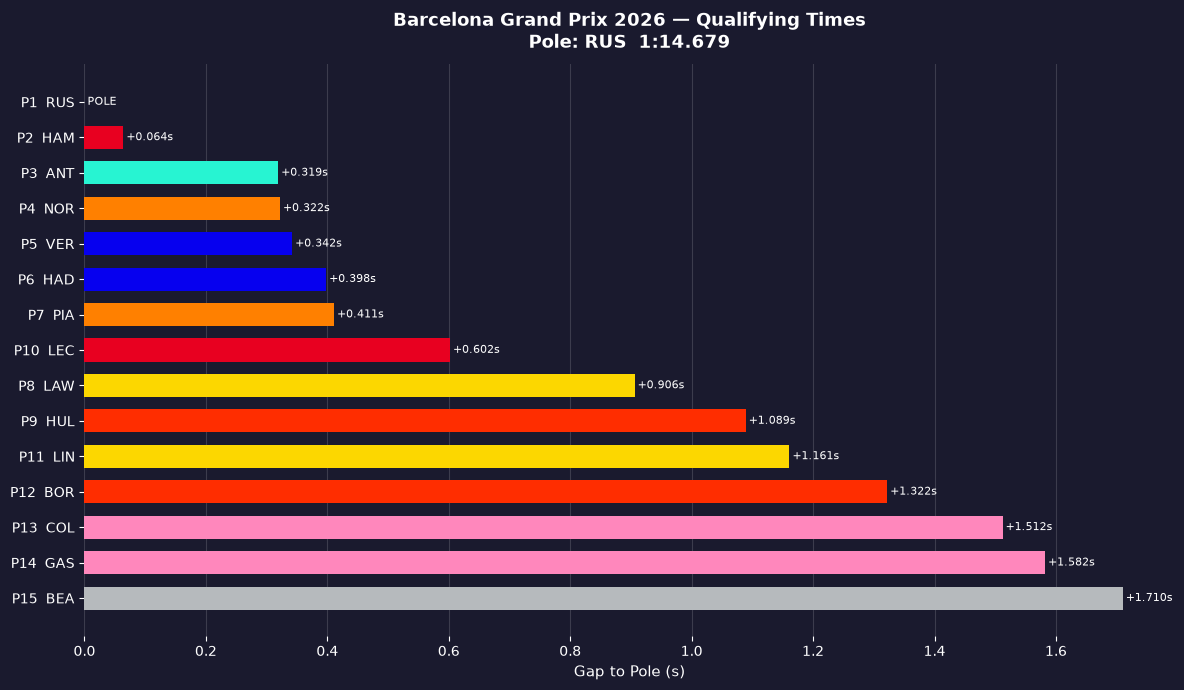

In [5]:
fig_q1 = plot_qualifying_times(quali, top_n=15, assets_path=ASSETS)
fig_q1.show()

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWa

Saved → assets\Q2_sector_times.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\3036355809.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_q2.show()


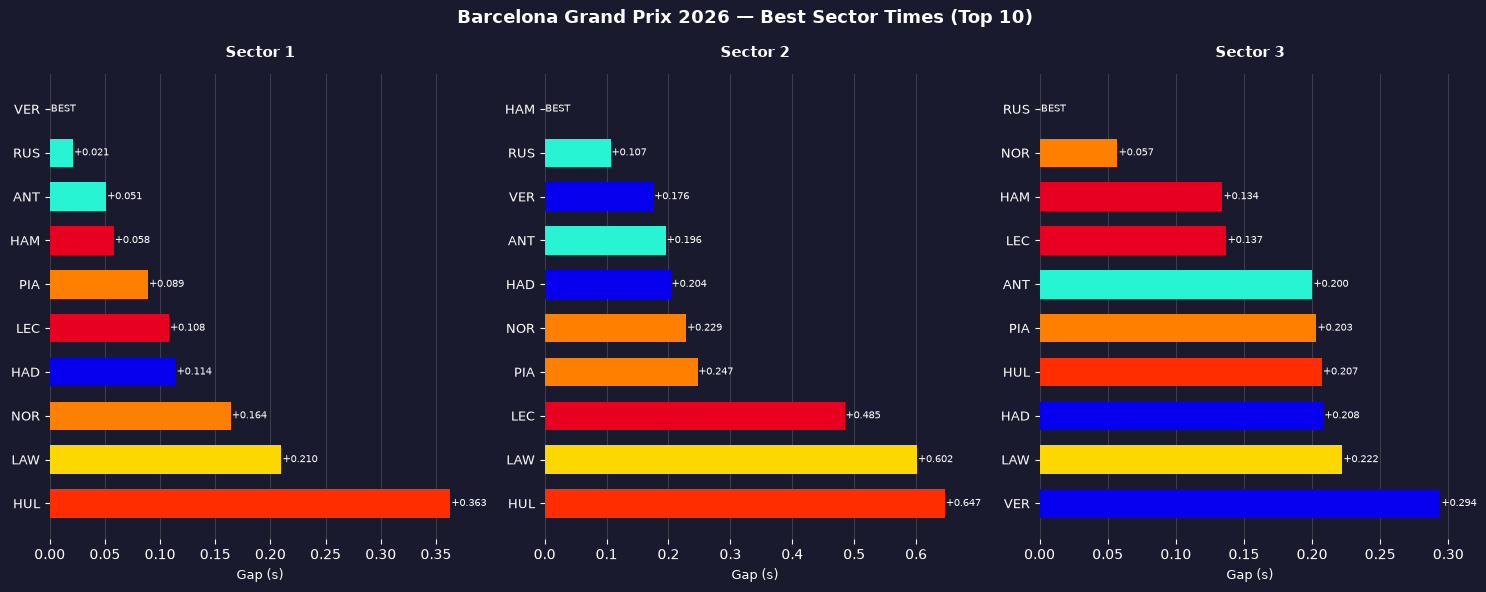

In [6]:
fig_q2 = plot_sector_times(quali, top_n=10, assets_path=ASSETS)
fig_q2.show()

---
## 2 · Sprint Weekend *(skip if `HAS_SPRINT = False`)*

In [7]:
if HAS_SPRINT:
    print('=== Sprint Shootout ===')
    fig_sq = plot_qualifying_times(sprint_quali, top_n=15, assets_path=ASSETS)
    # rename file so it doesn't overwrite Q chart
    import os, shutil
    shutil.move(f'{ASSETS}/Q1_qualifying_times.png', f'{ASSETS}/SQ1_shootout_times.png')
    fig_sq.show()
else:
    print('No Sprint this weekend — skipping.')

No Sprint this weekend — skipping.


In [8]:
if HAS_SPRINT:
    print('=== Sprint Race ===')
    fig_sr1 = plot_race_results(sprint, assets_path=ASSETS)
    shutil.move(f'{ASSETS}/01_race_results.png', f'{ASSETS}/S1_sprint_results.png')
    fig_sr1.show()

    fig_sr2 = plot_lap_times(sprint, assets_path=ASSETS)
    shutil.move(f'{ASSETS}/02_lap_time_evolution.png', f'{ASSETS}/S2_sprint_lap_times.png')
    fig_sr2.show()
else:
    print('No Sprint this weekend — skipping.')

No Sprint this weekend — skipping.


---
## 3 · Race

In [9]:
race_results = get_race_results(race)
race_results.head(10)

,Position,FullName,TeamName,Points,Status,Time
0,1.0,Lewis Hamilton,Ferrari,25.0,Finished,0 days 01:32:28.105000
1,2.0,George Russell,Mercedes,18.0,Finished,0 days 00:00:19.561000
2,3.0,Lando Norris,McLaren,15.0,Finished,0 days 00:00:23.719000
3,4.0,Max Verstappen,Red Bull Racing,12.0,Finished,0 days 00:00:40.497000
4,5.0,Oscar Piastri,McLaren,10.0,Finished,0 days 00:00:58.661000
5,6.0,Isack Hadjar,Red Bull Racing,8.0,Lapped,0 days 00:00:24.627000
6,7.0,Pierre Gasly,Alpine,6.0,Lapped,0 days 00:00:55.789000
7,8.0,Liam Lawson,Racing Bulls,4.0,Lapped,0 days 00:01:12.224000
8,9.0,Arvid Lindblad,Racing Bulls,2.0,Lapped,0 days 00:01:18.074000
9,10.0,Franco Colapinto,Alpine,1.0,Lapped,0 days 00:01:19.867000


req            INFO 	Using cached data for driver_info


Saved → assets\01_race_results.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\2427579830.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_r1.show()


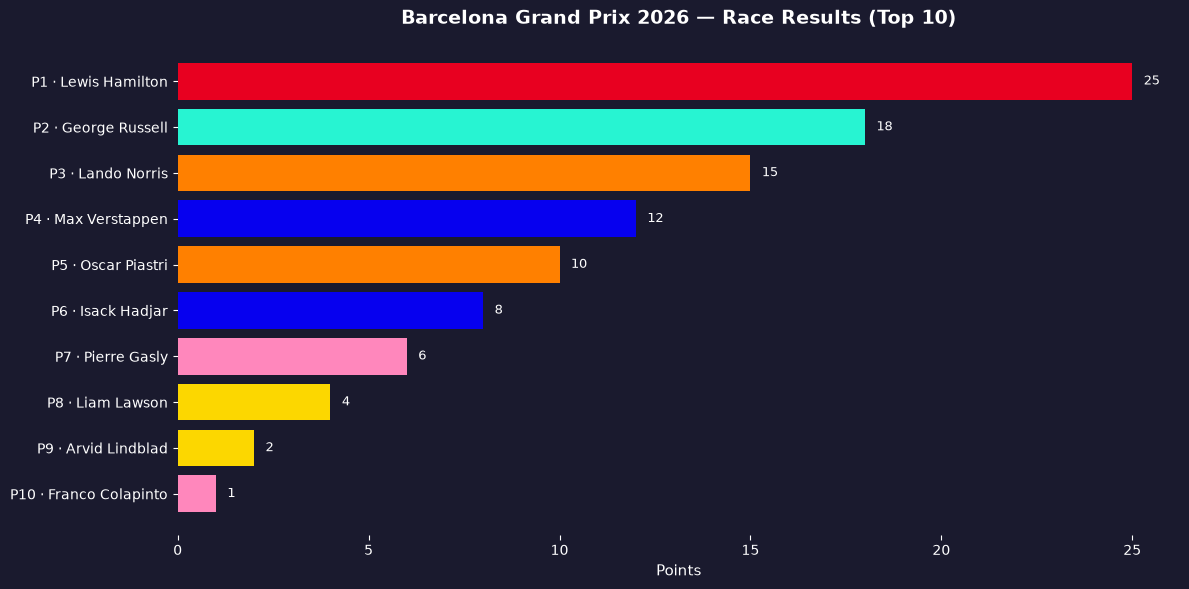

In [10]:
fig_r1 = plot_race_results(race, ASSETS)
fig_r1.show()

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Saved → assets\02_lap_time_evolution.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\3878794663.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_r2.show()


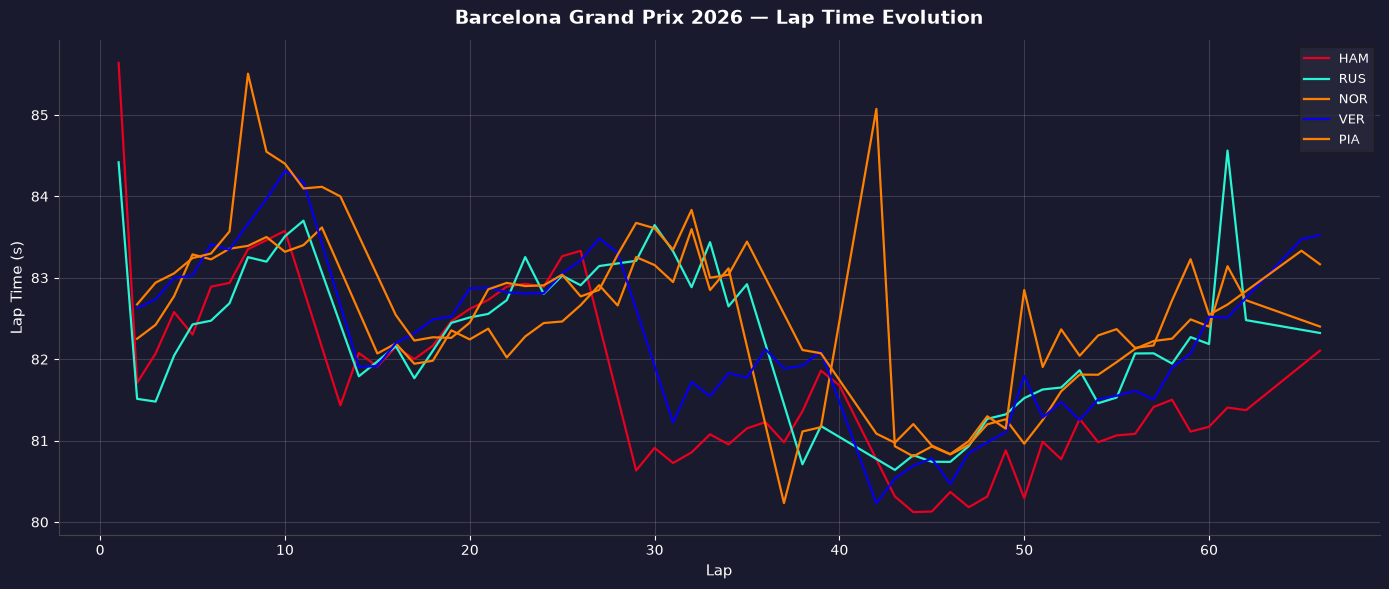

In [11]:
fig_r2 = plot_lap_times(race, assets_path=ASSETS)
fig_r2.show()

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWa

Saved → assets\03_tyre_strategy.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\3235859558.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_r3.show()


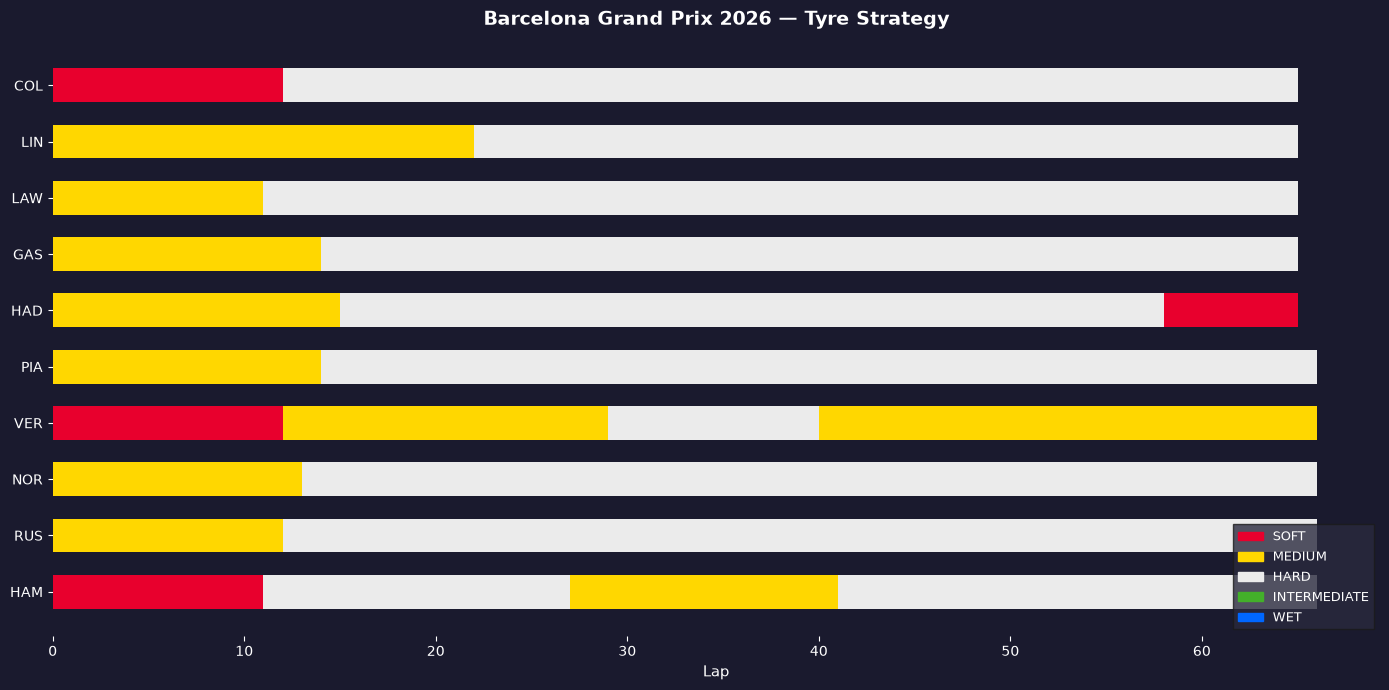

In [12]:
fig_r3 = plot_tyre_strategy(race, ASSETS)
fig_r3.show()

In [13]:
if DRIVER_1 is None or DRIVER_2 is None:
    top2 = race_results.head(2)
    DRIVER_1 = race.results[race.results['FullName'] == top2.iloc[0]['FullName']]['Abbreviation'].values[0]
    DRIVER_2 = race.results[race.results['FullName'] == top2.iloc[1]['FullName']]['Abbreviation'].values[0]
print(f'Telemetry comparison: {DRIVER_1} vs {DRIVER_2}')

Telemetry comparison: HAM vs RUS


e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Saved → assets\04_telemetry_HAM_vs_RUS.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\2663217943.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_r4.show()


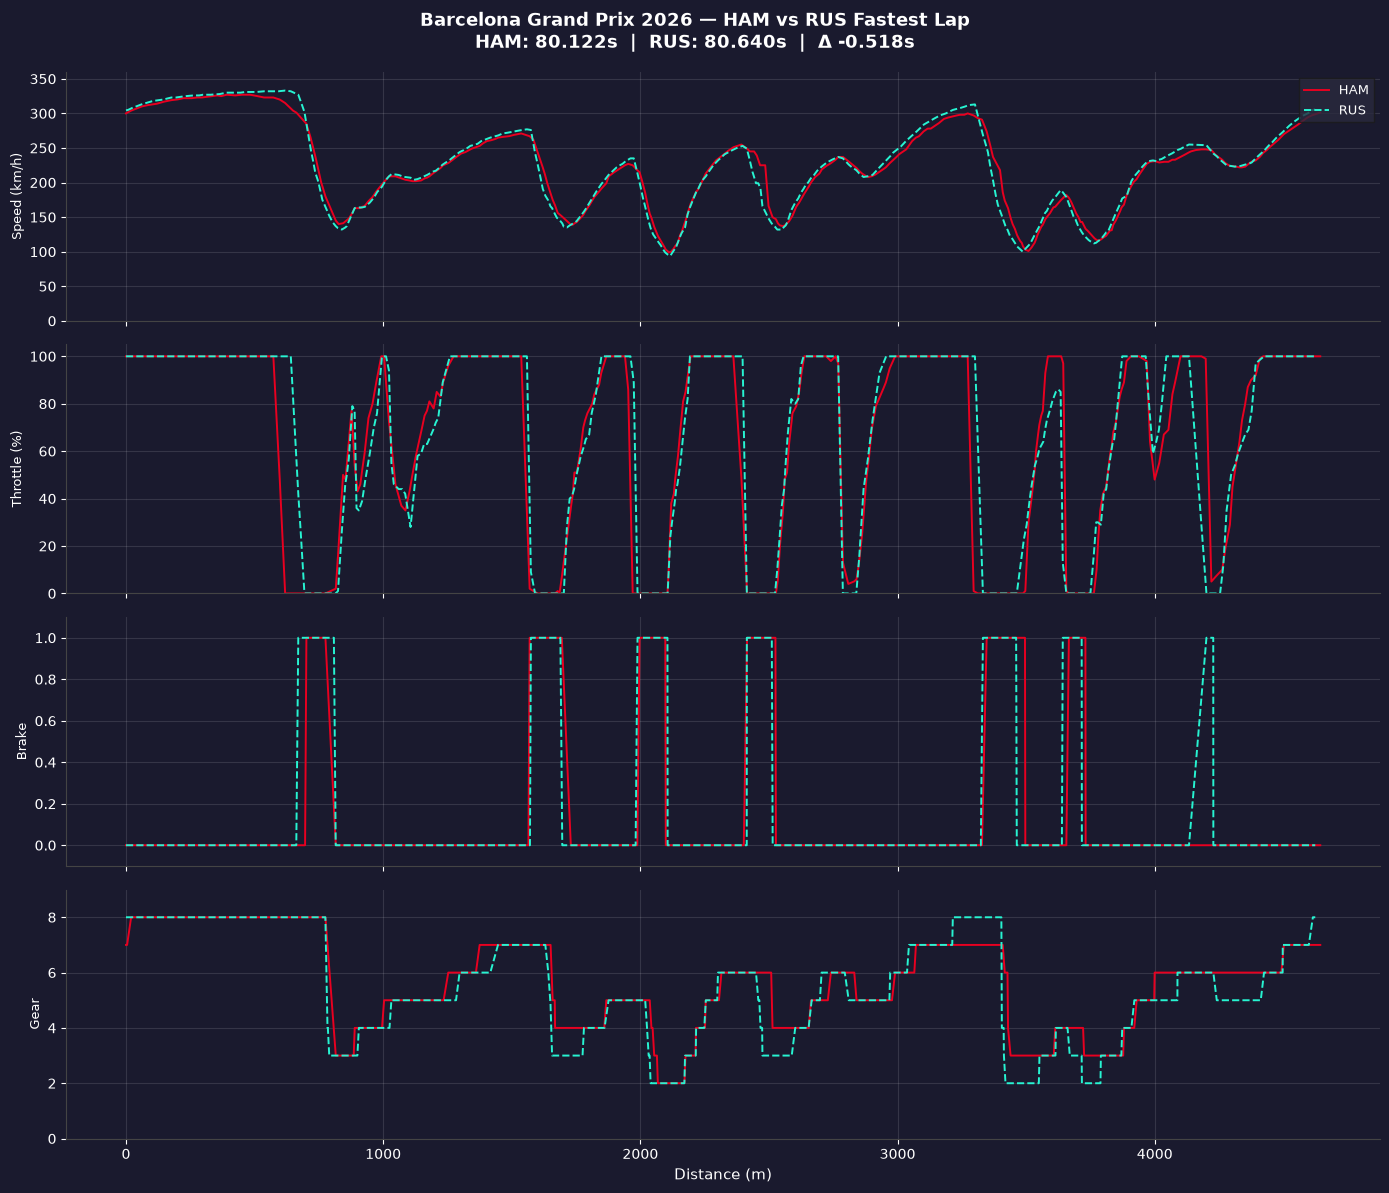

In [14]:
fig_r4 = plot_telemetry(race, DRIVER_1, DRIVER_2, ASSETS)
fig_r4.show()

---
## 4 · Weekend Summary

Saved → assets\W1_positions_gained.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_60052\4049845221.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_w1.show()


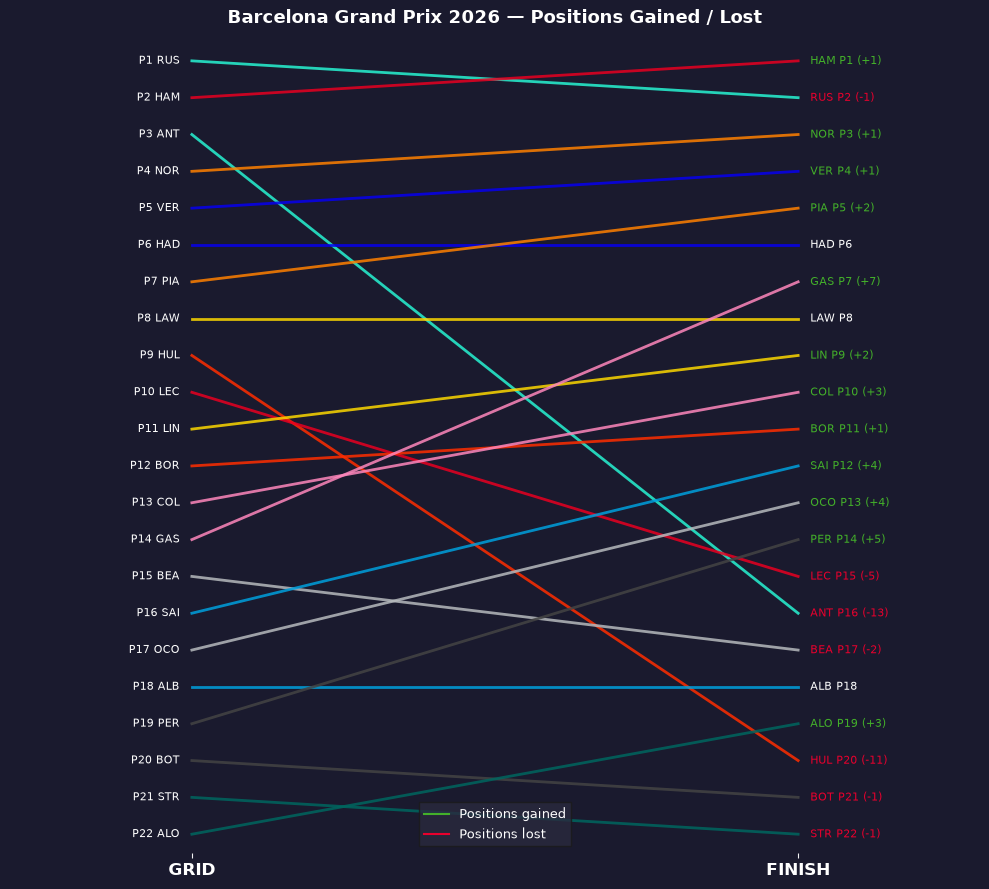

In [15]:
# Grid position (from qualifying) vs final race position
fig_w1 = plot_positions_gained(race, ASSETS)
fig_w1.show()

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
findfont: Failed to find font weight medium, now using 400.
C:\Users

Saved → assets\W2_pace_comparison.png


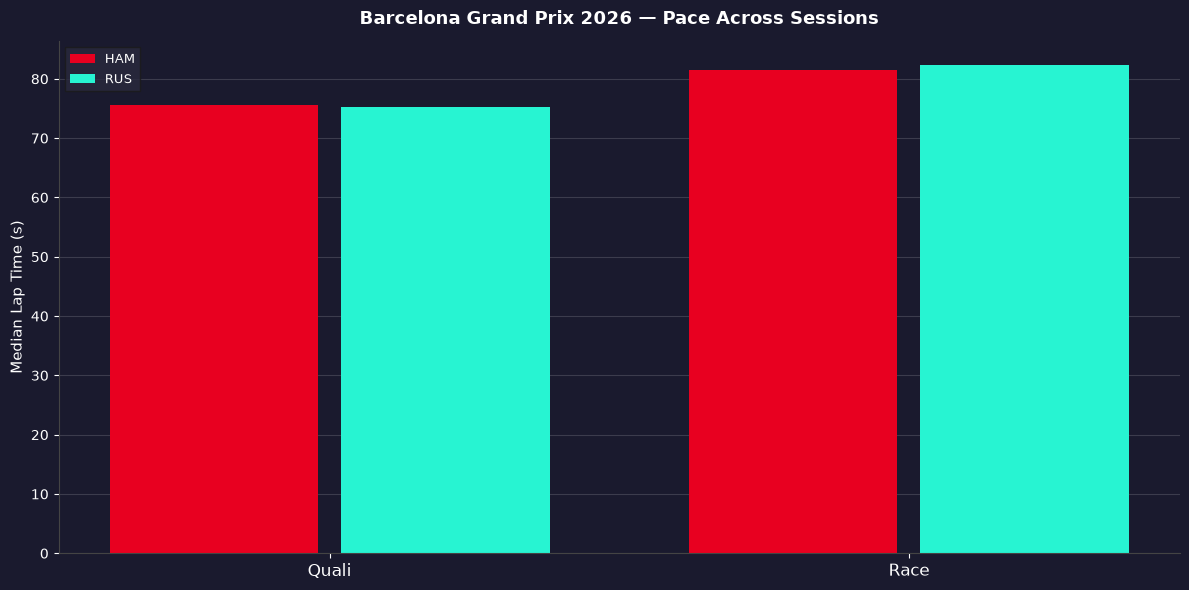

In [16]:
# Median pace per session for the two focus drivers
sessions_map = {'Quali': quali, 'Race': race}
if HAS_SPRINT:
    sessions_map = {'Quali': quali, 'Sprint': sprint, 'Race': race}

fig_w2 = plot_pace_comparison(sessions_map, drivers=[DRIVER_1, DRIVER_2], assets_path=ASSETS)
fig_w2.show()

---
## 5 · LinkedIn Post Draft

In [17]:
winner     = race_results.iloc[0]['FullName']
p2         = race_results.iloc[1]['FullName']
p3         = race_results.iloc[2]['FullName']
event_name = race.event['EventName']
pole       = quali_df.iloc[0]['FullName']

post = f"""
🏁 {event_name} {YEAR} — Full Weekend in Data

[HOOK — e.g.: {pole} took pole, but was it really their weekend?]

🔵 Qualifying:
· Pole: {pole} | [delta between P1 and P2 from chart]
· [Key sector time insight]

{'🟡 Sprint: [key sprint insight]' if HAS_SPRINT else ''}

🔴 Race:
· P1 {winner} · P2 {p2} · P3 {p3}
· [Tyre strategy insight]
· [Telemetry insight: {DRIVER_1} vs {DRIVER_2}]

📊 Biggest mover: [from positions gained chart]

💡 [1-2 sentence story of the weekend in data]

What was your highlight of the weekend? 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #{event_name.replace(' ', '')}
"""

print(post)


🏁 Barcelona Grand Prix 2026 — Full Weekend in Data

[HOOK — e.g.: George Russell took pole, but was it really their weekend?]

🔵 Qualifying:
· Pole: George Russell | [delta between P1 and P2 from chart]
· [Key sector time insight]



🔴 Race:
· P1 Lewis Hamilton · P2 George Russell · P3 Lando Norris
· [Tyre strategy insight]
· [Telemetry insight: HAM vs RUS]

📊 Biggest mover: [from positions gained chart]

💡 [1-2 sentence story of the weekend in data]

What was your highlight of the weekend? 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #BarcelonaGrandPrix



---
## Assets generated

| File | Section | LinkedIn use |
|------|---------|-------------|
| `Q1_qualifying_times.png` | Qualifying | Image 1 |
| `Q2_sector_times.png` | Qualifying | Image 2 |
| `SQ1_shootout_times.png` | Sprint Shootout | Image 3 (Sprint only) |
| `S1_sprint_results.png` | Sprint Race | Image 4 (Sprint only) |
| `01_race_results.png` | Race | Image 3 or 5 |
| `02_lap_time_evolution.png` | Race | Image 4 or 6 |
| `03_tyre_strategy.png` | Race | High engagement |
| `04_telemetry_*.png` | Race | Most technical |
| `W1_positions_gained.png` | Weekend | Strong visual |
| `W2_pace_comparison.png` | Weekend | Clean summary |

**Commit:**
```bash
git add 2026/R{round}_{location}/
git commit -m "feat: {event_name} {year} weekend analysis"
git push
```